In [275]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x268c7a01400>)

In [276]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

df_stars = pd.read_csv("stars.csv")

In [277]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [281]:
df_stars.isna().sum() 

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [283]:
(df_stars == "").sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [285]:
(df_stars == -999).sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [287]:
df_stars.dtypes

Temperature (K)             int64
Luminosity(L/Lo)          float64
Radius(R/Ro)              float64
Absolute magnitude(Mv)    float64
Star type                  object
Star color                 object
Spectral Class             object
dtype: object

In [289]:
df_num = df_stars.select_dtypes(include="number")

(df_num <= 0).sum()

Temperature (K)             0
Luminosity(L/Lo)            0
Radius(R/Ro)                0
Absolute magnitude(Mv)    102
dtype: int64

In [291]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


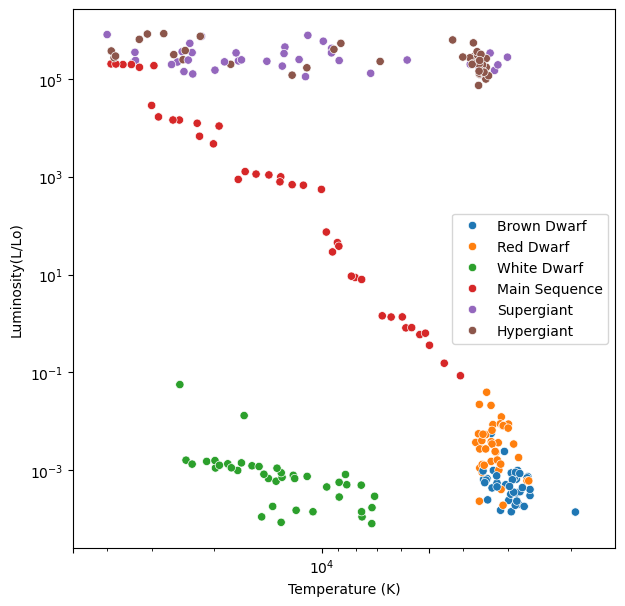

In [293]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [295]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


In [297]:
#df_stars.drop(["log_T", "log_L", "log_R", "log_M"], axis=1, inplace=True)

In [299]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


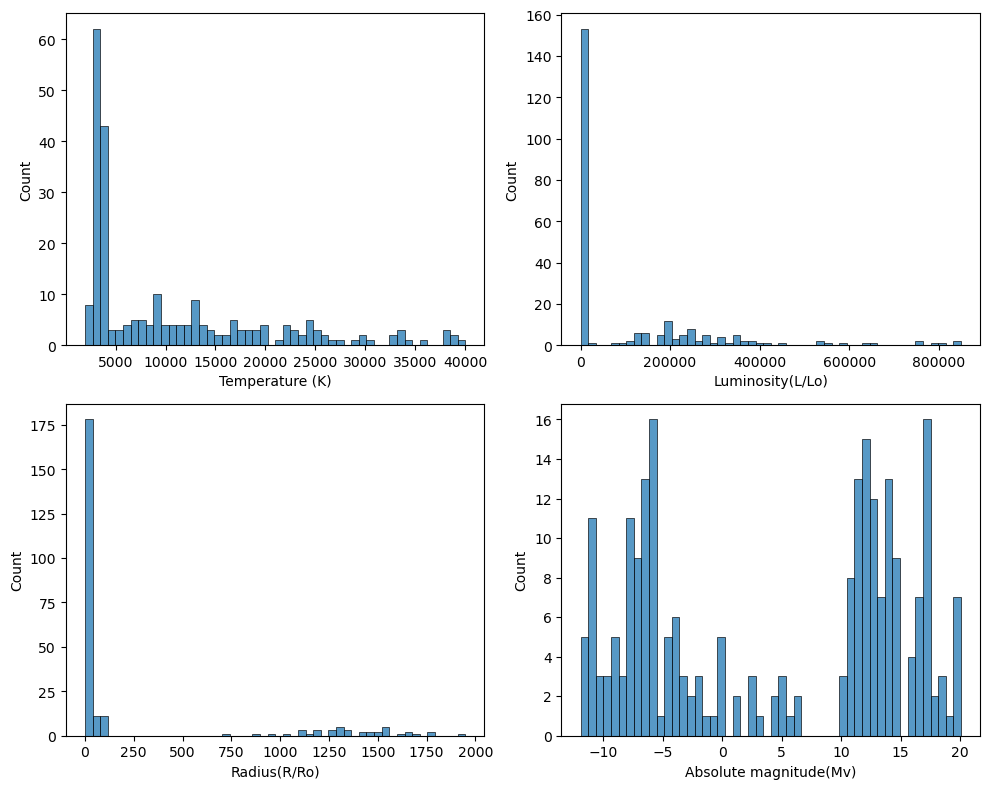

In [301]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df_stars["Temperature (K)"], bins=50, ax=axs[0, 0])
sns.histplot(df_stars["Luminosity(L/Lo)"], bins=50, ax=axs[0, 1])
sns.histplot(df_stars["Radius(R/Ro)"], bins=50, ax=axs[1, 0])
sns.histplot(df_stars["Absolute magnitude(Mv)"], bins=50, ax=axs[1, 1])

plt.tight_layout()
plt.show()

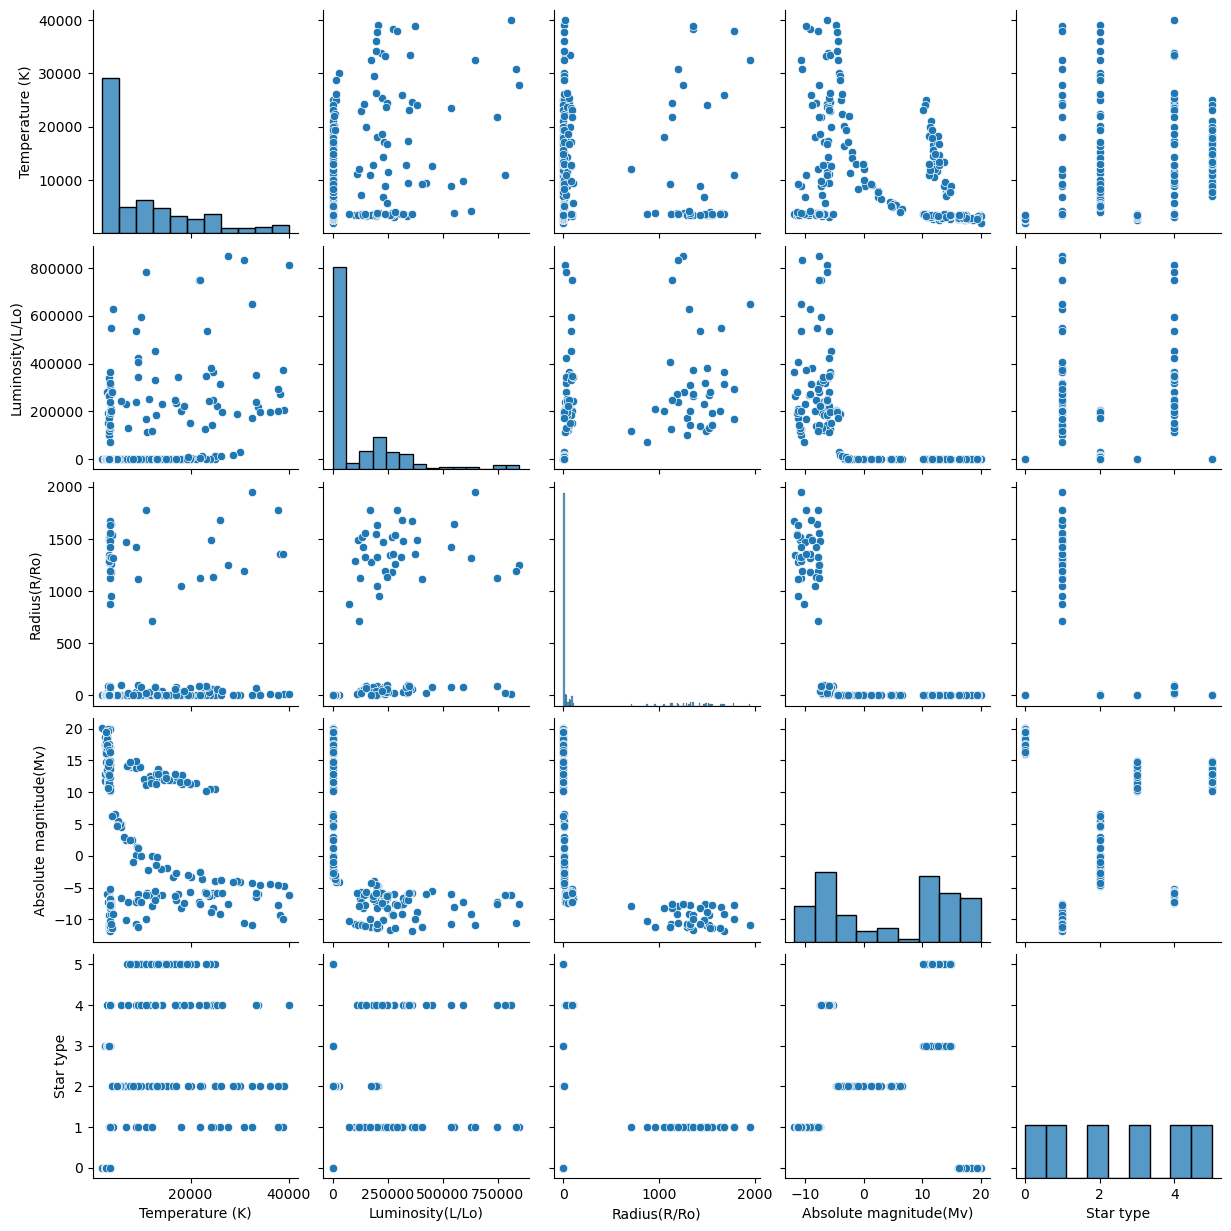

In [302]:
sns.pairplot(df_stars)
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue

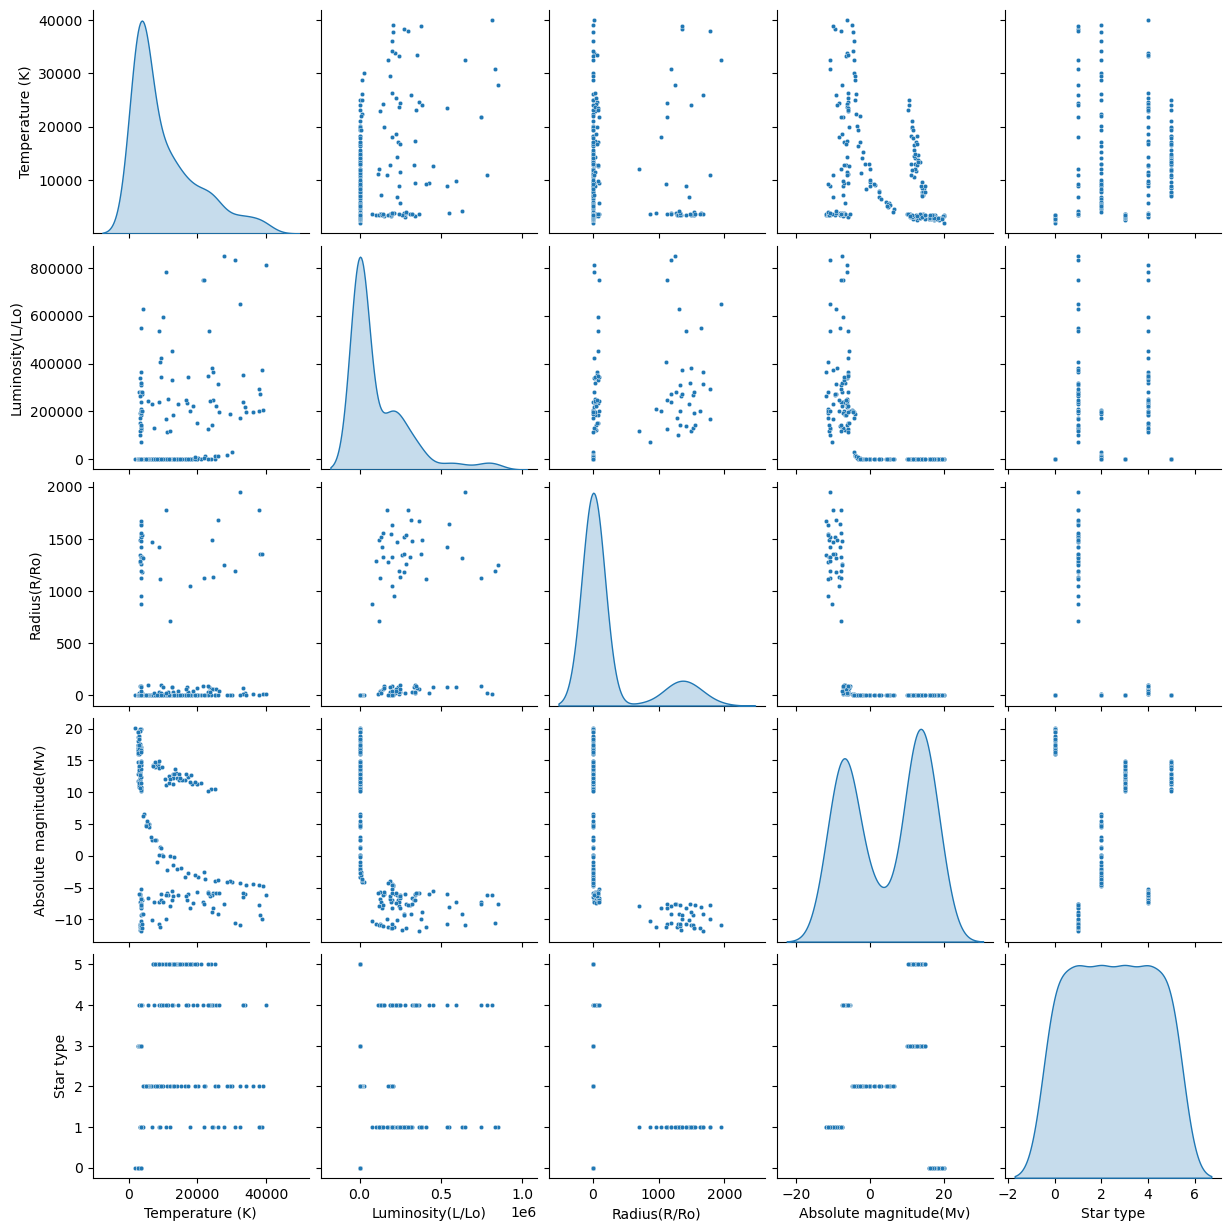

In [304]:
sns.pairplot(
    df_stars,
    palette="viridis",
    diag_kind="kde", 
    plot_kws={"s": 10, "alpha": 1}
)

In [305]:
Mv = df_stars['Absolute magnitude(Mv)']
L = df_stars["Luminosity(L/Lo)"]
radius = df_stars["Radius(R/Ro)"]
T = df_stars["Temperature (K)"]

### let's now compute PCA 

In [307]:
arr_stars = df_num.to_numpy()

<Axes: xlabel='PC1', ylabel='PC2'>

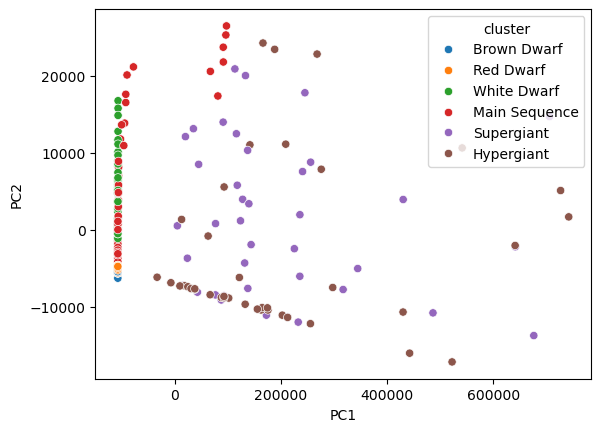

In [308]:
arr_stars = df_num.to_numpy()
pca = PCA(n_components=2) # n_components can be optionally set
pca.fit(arr_stars) 
projected_data = pca.transform(arr_stars)
#projected_data = pca.fit_transform(arr_stars) equivalent

df_pca = pd.DataFrame({
    "PC1": projected_data[:,0],
    "PC2": projected_data[:,1],
    "cluster": labels
})

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster")

In [324]:
from sklearn.preprocessing import StandardScaler

In [330]:
scale = StandardScaler()
data_scale = scale.fit_transform(arr_stars) #understand better why it works

<Axes: xlabel='PC1', ylabel='PC2'>

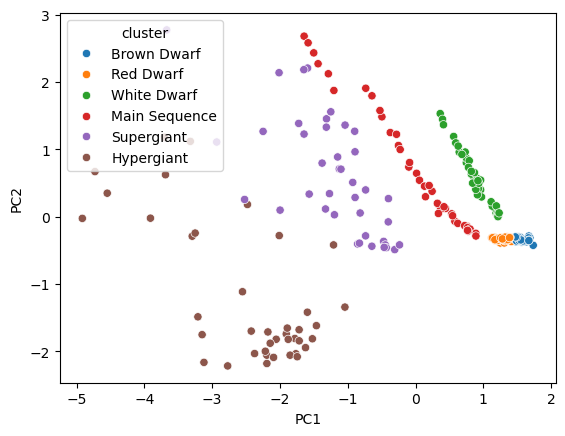

In [332]:
pca = PCA(n_components=2) # n_components can be optionally set
pca.fit(data_scale) 
projected_data_scale = pca.transform(data_scale)
#projected_data = pca.fit_transform(arr_stars) equivalent

df_pca_scale = pd.DataFrame({
    "PC1": projected_data_scale[:,0],
    "PC2": projected_data_scale[:,1],
    "cluster": labels
})

sns.scatterplot(data=df_pca_scale, x="PC1", y="PC2", hue="cluster")

In [334]:
pca.explained_variance_ratio_

array([0.60357391, 0.23500784])